<a href="https://colab.research.google.com/github/giyuubin/group-project/blob/feat%2Fcode-upload/LR_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 로지스틱 회귀(Logistic Regression) 모델 학습 파이프라인 시작...

[1/4] 데이터 불러오는 중...
✅ 데이터 로드 완료!

[2/4] 로지스틱 회귀 모델 학습 중...
✅ 학습 완료! (소요 시간: 1.164초)

[3/4] Test Set 대상 추론 및 성능 평가 중...
----------------------------------------
📊 [Logistic Regression 최종 성능]
  - Accuracy (정확도) : 90.58%
  - Recall   (재현율) : 90.93%
  - Precision(정밀도) : 99.19%
  - F1-Score (F1점수) : 0.9488
  - 1샘플당 추론 속도 : 0.001 ms
----------------------------------------

[4/4] 훈련된 모델 파일(.joblib) 저장 중...
✅ 모델 저장 완료! (파일명: model_lr_박규빈.joblib)
🎉 이 파일을 벤치마크 취합 담당자에게 전달해 주세요!

📉 혼동 행렬(Confusion Matrix) 시각화 출력 중...


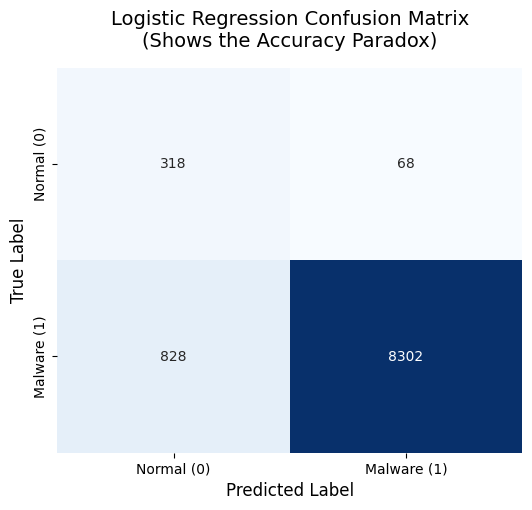


상세 분류 리포트:
              precision    recall  f1-score   support

  Normal (0)       0.28      0.82      0.42       386
 Malware (1)       0.99      0.91      0.95      9130

    accuracy                           0.91      9516
   macro avg       0.63      0.87      0.68      9516
weighted avg       0.96      0.91      0.93      9516



In [1]:
import pandas as pd
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

print("🚀 로지스틱 회귀(Logistic Regression) 모델 학습 파이프라인 시작...\n")

# 1. 데이터 로드 (팀 공통 가이드라인 준수)
# 주의: 파일 경로는 규빈님의 실제 로컬 환경에 맞게 수정해 주세요.
print("[1/4] 데이터 불러오는 중...")
try:
    # SMOTE가 적용된 1:1 균형 훈련 데이터
    train_df = pd.read_csv('optimized_data_train.csv')
    X_train = train_df.drop(columns=['malware'])
    y_train = train_df['malware']

    # 1:23 불균형 원본 테스트 데이터
    test_df = pd.read_csv('optimized_data_test.csv')
    X_test = test_df.drop(columns=['malware'])
    y_test = test_df['malware']
    print("✅ 데이터 로드 완료!\n")
except FileNotFoundError:
    print("❌ 에러: CSV 파일을 찾을 수 없습니다. 경로를 확인해 주세요.\n")

# 2. 모델 정의 및 학습
print("[2/4] 로지스틱 회귀 모델 학습 중...")
# 팀 규칙에 따라 random_state=42 고정, 수렴을 위해 max_iter를 1000으로 여유 있게 설정
lr_model = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
lr_model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"✅ 학습 완료! (소요 시간: {train_time:.3f}초)\n")

# 3. 추론 및 모델 평가
print("[3/4] Test Set 대상 추론 및 성능 평가 중...")
inference_start = time.time()
y_pred = lr_model.predict(X_test)
inference_time = time.time() - inference_start
inference_time_ms = (inference_time * 1000) / len(X_test)

# 평가 지표 계산
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("-" * 40)
print(f"📊 [Logistic Regression 최종 성능]")
print(f"  - Accuracy (정확도) : {acc * 100:.2f}%")
print(f"  - Recall   (재현율) : {recall * 100:.2f}%")
print(f"  - Precision(정밀도) : {precision * 100:.2f}%")
print(f"  - F1-Score (F1점수) : {f1:.4f}")
print(f"  - 1샘플당 추론 속도 : {inference_time_ms:.3f} ms")
print("-" * 40 + "\n")

# 4. 모델 저장 (벤치마크 제출용)
print("[4/4] 훈련된 모델 파일(.joblib) 저장 중...")
model_filename = 'model_lr_박규빈.joblib'
joblib.dump(lr_model, model_filename)
print(f"✅ 모델 저장 완료! (파일명: {model_filename})")
print("🎉 이 파일을 벤치마크 취합 담당자에게 전달해 주세요!\n")

# ---------------------------------------------------------
# (보너스) 교수님 방어용 '정확도의 역설' 시각화 (혼동 행렬)
# ---------------------------------------------------------
print("📉 혼동 행렬(Confusion Matrix) 시각화 출력 중...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Malware (1)'],
            yticklabels=['Normal (0)', 'Malware (1)'])
plt.title('Logistic Regression Confusion Matrix\n(Shows the Accuracy Paradox)', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("\n상세 분류 리포트:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Malware (1)']))